# WikiQA — Dataset Exploration

The WikiQA corpus contains questions paired with candidate answer sentences from Wikipedia.
Each row has a `Label`: `1` = correct answer, `0` = irrelevant sentence.
For our chatbot we only care about the `Label=1` pairs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../data/raw"

train = pd.read_csv(f"{DATA_DIR}/WikiQA-train.tsv", sep="\t")
dev = pd.read_csv(f"{DATA_DIR}/WikiQA-dev.tsv", sep="\t")
test = pd.read_csv(f"{DATA_DIR}/WikiQA-test.tsv", sep="\t")

print("Columns:", train.columns.tolist())
print(
    f"\nRaw row counts  — train: {len(train):,}  dev: {len(dev):,}  test: {len(test):,}"
)

Columns: ['QuestionID', 'Question', 'DocumentID', 'DocumentTitle', 'SentenceID', 'Sentence', 'Label']

Raw row counts  — train: 20,347  dev: 2,733  test: 6,116


## Label distribution

Most candidate sentences are negatives (`Label=0`). Let's see the ratio.

In [2]:
for name, df in [("train", train), ("dev", dev), ("test", test)]:
    counts = df["Label"].value_counts().sort_index()
    pct = counts[1] / len(df) * 100
    print(
        f"{name:5s}  Label=0: {counts[0]:,}  Label=1: {counts[1]:,}  ({pct:.1f}% positive)"
    )

train  Label=0: 19,308  Label=1: 1,039  (5.1% positive)
dev    Label=0: 2,593  Label=1: 140  (5.1% positive)
test   Label=0: 5,825  Label=1: 291  (4.8% positive)


## Q&A pairs (Label=1 only)

Filter each split down to just the correct answer rows — these are the pairs we train on.

In [3]:
train_qa = train[train["Label"] == 1][["Question", "Sentence"]].reset_index(drop=True)
dev_qa = dev[dev["Label"] == 1][["Question", "Sentence"]].reset_index(drop=True)
test_qa = test[test["Label"] == 1][["Question", "Sentence"]].reset_index(drop=True)

print(
    f"Q&A pairs  — train: {len(train_qa):,}  dev: {len(dev_qa):,}  test: {len(test_qa):,}"
)
train_qa.head(5)

Q&A pairs  — train: 1,039  dev: 140  test: 291


,Question,Sentence
0,how are glacier caves formed?,A glacier cave is a cave formed within the ice...
1,how much is 1 tablespoon of water,This tablespoon has a capacity of about 15 mL.
2,how much is 1 tablespoon of water,In the USA one tablespoon (measurement unit) i...
3,how much is 1 tablespoon of water,In Australia one tablespoon (measurement unit)...
4,how much are the harry potter movies worth,The series also originated much tie-in merchan...


## Sequence length distributions

Word counts for questions and answers — useful for deciding padding/truncation limits.

In [4]:
train_qa["q_len"] = train_qa["Question"].str.split().str.len()
train_qa["a_len"] = train_qa["Sentence"].str.split().str.len()

print("Question length stats:")
print(train_qa["q_len"].describe().to_string())
print("\nAnswer length stats:")
print(train_qa["a_len"].describe().to_string())

Question length stats:
count    1039.000000
mean        6.204042
std         1.873850
min         3.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        19.000000

Answer length stats:
count    1039.000000
mean       26.811357
std        12.449243
min         1.000000
25%        18.000000
50%        24.000000
75%        34.000000
max       166.000000


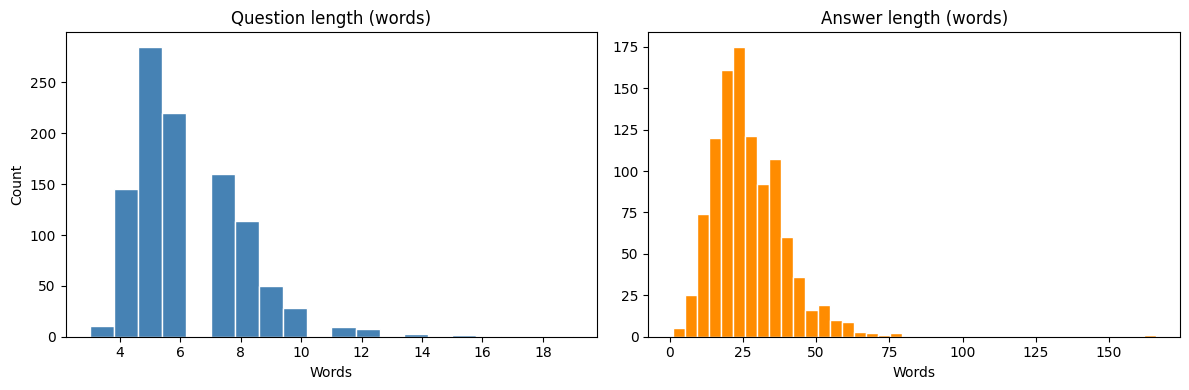

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_qa["q_len"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Question length (words)")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Count")

axes[1].hist(train_qa["a_len"], bins=40, color="darkorange", edgecolor="white")
axes[1].set_title("Answer length (words)")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

## Vocabulary size

Rough estimate of unique tokens in the training questions and answers.

In [6]:
all_tokens = (
    " ".join(train_qa["Question"].tolist() + train_qa["Sentence"].tolist())
    .lower()
    .split()
)
vocab = set(all_tokens)

print(f"Total tokens (train) : {len(all_tokens):,}")
print(f"Unique tokens        : {len(vocab):,}")

Total tokens (train) : 34,303
Unique tokens        : 9,054


## Sample Q&A pairs

In [7]:
for _, row in train_qa.sample(8, random_state=42).iterrows():
    print(f"Q: {row['Question']}")
    print(f"A: {row['Sentence']}")
    print()

Q: what branch of the military is delta force
A: It was formerly listed as the Combat Applications Group by the Department of Defense but has since been officially re-designated the Army Compartmented Elements (ACE).

Q: what is the controlled substance act known as
A: The Controlled Substances Act (CSA) was enacted into law by the Congress of the United States as Title II of the Comprehensive Drug Abuse Prevention and Control Act of 1970 .

Q: how many innings makes an official game
A: Since most professional baseball games are nine innings long, the fifth inning is used as the threshold for an official game.

Q: how do forensic auditors examine financial reporting
A: Financial audits are typically performed by firms of practicing accountants who are experts in financial reporting.

Q: who created the tourbillon movement?
A: Developed around 1795 by the French-Swiss watchmaker Abraham-Louis Breguet from an earlier idea by the English chronometer maker John Arnold , a tourbillon aims t

## Questions with multiple correct answers

Some questions have more than one `Label=1` sentence — worth knowing before we decide how to handle them during training.

In [8]:
answers_per_q = train_qa.groupby("Question").size()
print(
    answers_per_q.value_counts()
    .rename_axis("answers per question")
    .reset_index(name="questions")
)

   answers per question  questions
0                     1        744
1                     2        103
2                     3         20
3                     7          2
4                     5          1
5                     6          1
6                     4          1
